In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [ ]:
from getpass import getpass

admin_rdm_url = 'https://admin.bh.rdm.yzwlab.com/' # 'https://admin.staging.rdm.example.com'
rdm_url = 'https://bh.rdm.yzwlab.com/' # 'https://staging.rdm.example.com'
idp_name_project_limit_1 = None
idp_username_project_limit_1 = None
idp_password_project_limit_1 = None

# 統合管理者用 (manager)
idp_name_integrated_admin = None
idp_username_integrated_admin = None
idp_password_integrated_admin = None

default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
if idp_name_project_limit_1 is None:
    idp_name_project_limit_1 = input(prompt=f'IdP Name: ')
if idp_username_project_limit_1 is None:
    idp_username_project_limit_1 = input(prompt=f'Username for {idp_name_project_limit_1}')
if idp_password_project_limit_1 is None:
    idp_password_project_limit_1 = getpass(prompt=f'Password for {idp_username_project_limit_1}@{idp_name_project_limit_1}')

if idp_name_integrated_admin is None:
    idp_name_integrated_admin = input(prompt=f'IdP Name for integrated admin: ')
if idp_username_integrated_admin is None:
    idp_username_integrated_admin = input(prompt=f'Username for {idp_name_integrated_admin} (integrated admin)')
if idp_password_integrated_admin is None:
    idp_password_integrated_admin = getpass(prompt=f'Password for {idp_username_integrated_admin}@{idp_name_integrated_admin}')

In [ ]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

# プロジェクト制限数_テンプレート作成・変更・削除

- サブシステム名: プロジェクト制限数
- ページ/アドオン: テンプレート作成・変更・削除
- 機能分類: テンプレート
- シナリオ名: プロジェクト制限数のテンプレート作成・変更・削除
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM, 統合管理者既存ユーザー: GRDM)

In [ ]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

## ウェブブラウザの新規プライベートウィンドウで GRDM トップページを表示する

GRDM トップページが表示されること


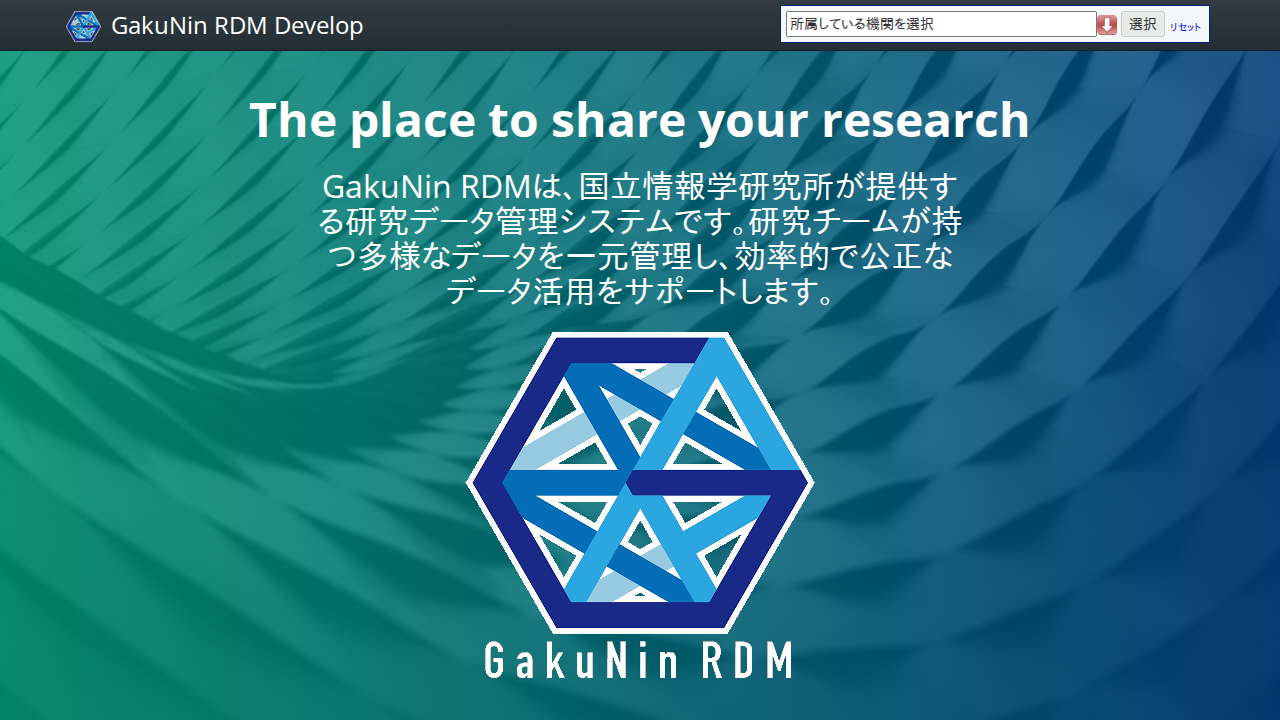

In [6]:
async def _step(page):
    await page.goto(rdm_url)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー1としてログインする

GRDM ダッシュボードが表示されること


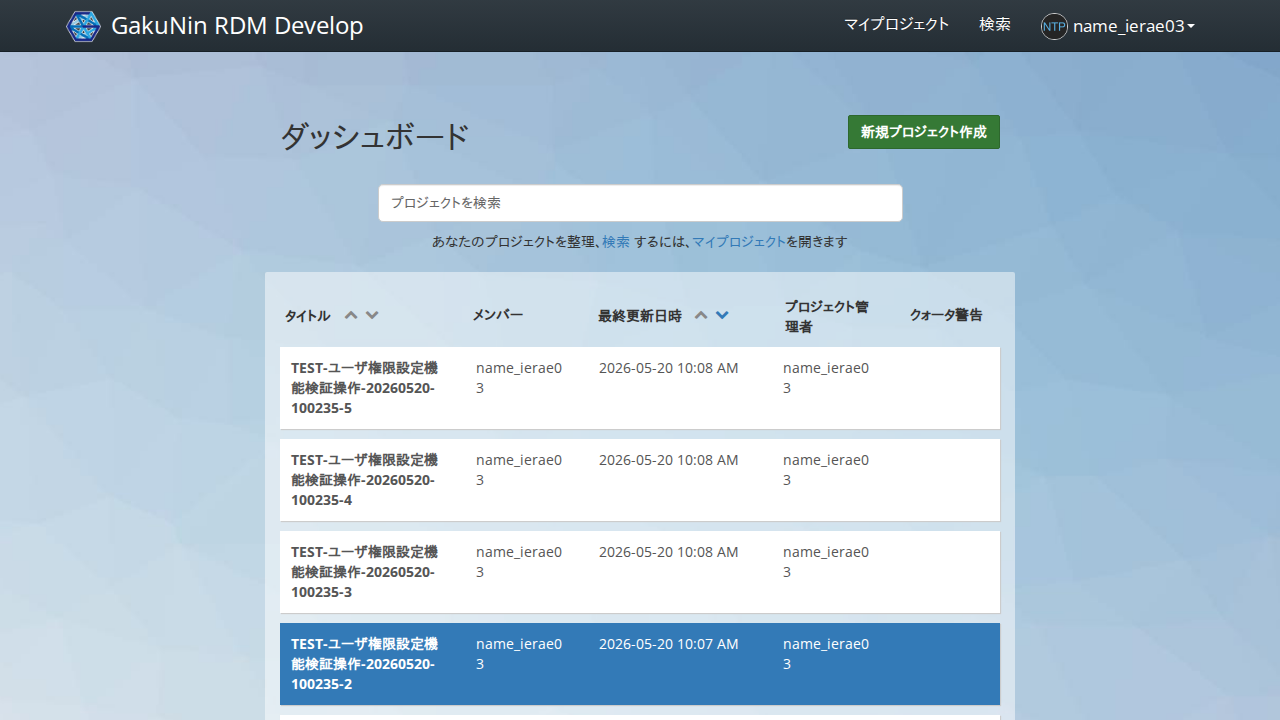

In [7]:
async def _step(page):
    await scripts.grdm.login(
        page, idp_name_project_limit_1, idp_username_project_limit_1, idp_password_project_limit_1, transition_timeout=transition_timeout
    )

    await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)

## 画面右上のユーザ名をクリックし、「設定」を選択する。

「設定」画面が表示されること


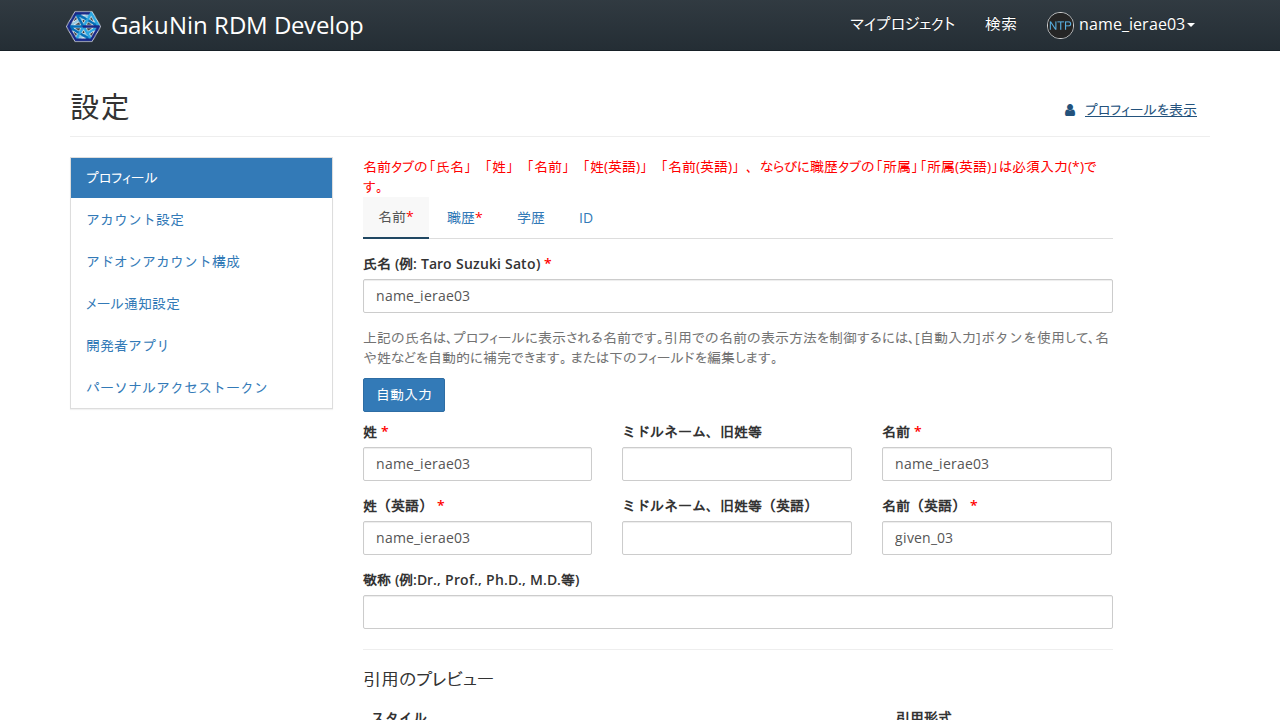

In [8]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await expect(page.locator('//*[@data-analytics-name="Settings"]')).to_be_visible(timeout=transition_timeout)

    await page.locator('//*[@data-analytics-name="Settings"]').click()
    await expect(page.locator('//*[text() = "アカウント設定"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 左のメニューから「アカウント設定」を選択する。

「登録メールアドレス」の「プライマリメール」を確認すること


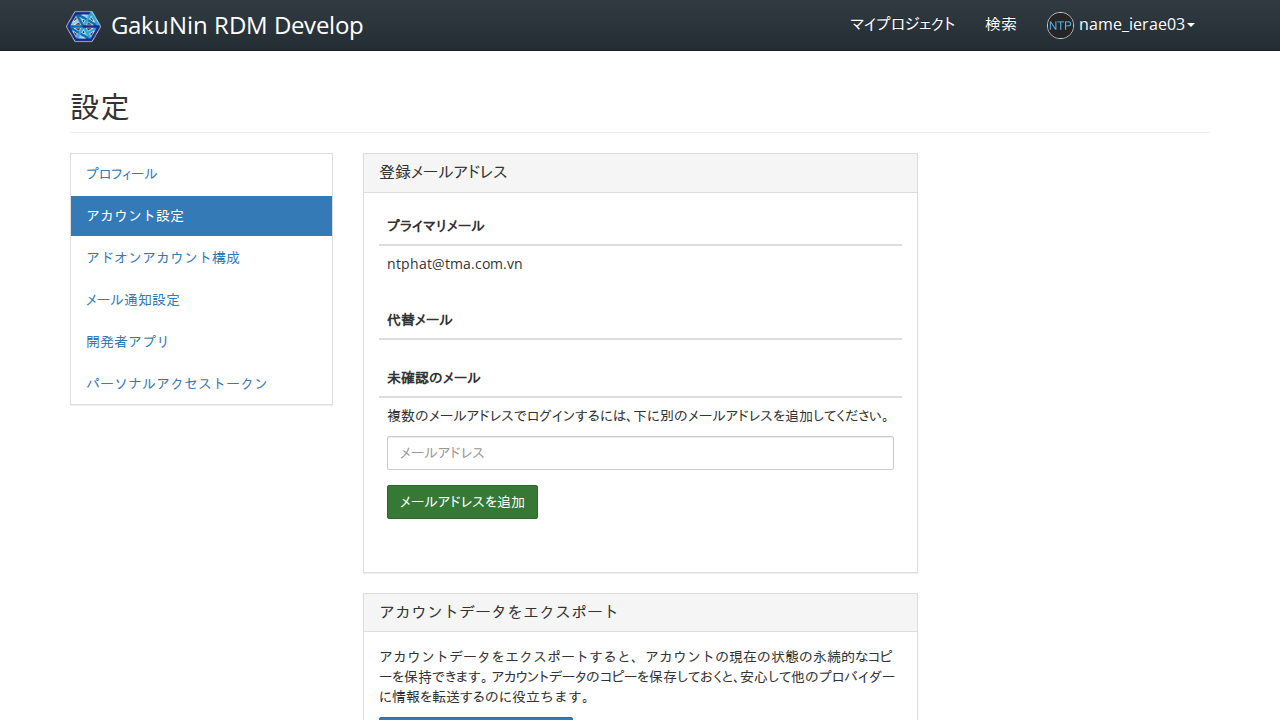

In [9]:
import os

async def _step(page):
    await page.locator('//*[text() = "アカウント設定"]').click()
    
    await expect(page.locator('[data-bind="text: profile().primaryEmail().address"]')).to_be_visible(timeout=transition_timeout)
    
    # Save primary email to a file
    primary_email = await page.locator('[data-bind="text: profile().primaryEmail().address"]').text_content()
    primary_email_file = os.path.join(default_result_path, 'primary_email.txt')

    with open(primary_email_file, 'w') as f:
        f.write(primary_email)

    print(f'Saved primary email to {primary_email_file}')

await run_pw(_step)

## ウェブブラウザの新規プライベートウィンドウで GRDM 管理者トップページを表示する

GRDM 管理者トップページが表示されること


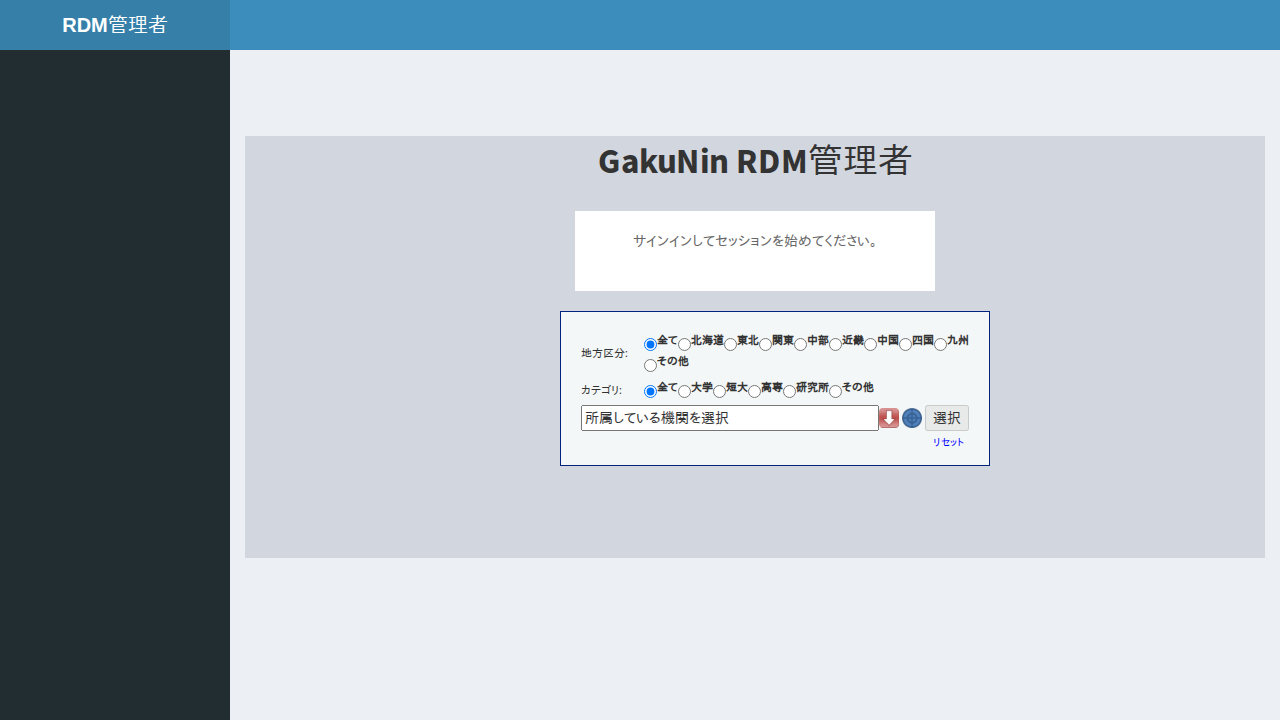

In [10]:
async def _step(page):
    await page.goto(admin_rdm_url)

    await expect(page.locator('.login-logo')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## アカウント(統合管理者既存ユーザー)を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

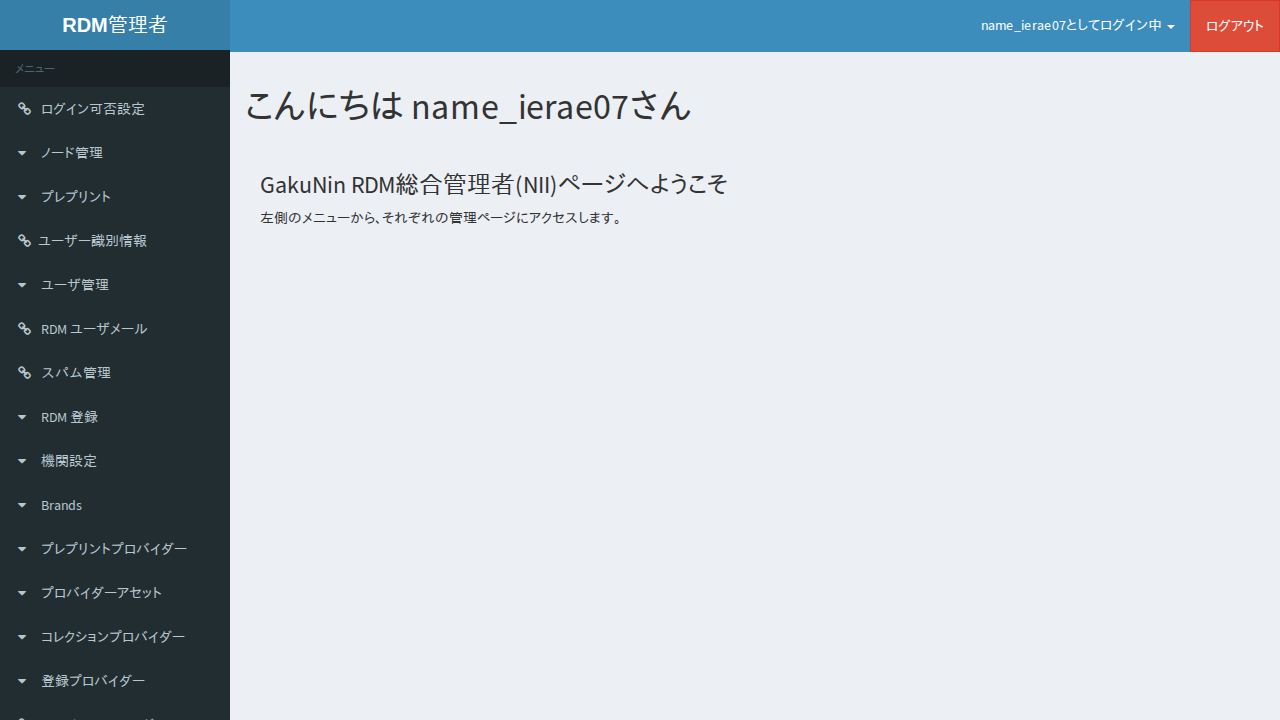

In [11]:
async def _step(page):
    await scripts.grdm.login_as_admin(
        page, idp_name_integrated_admin, idp_username_integrated_admin, idp_password_integrated_admin, transition_timeout=transition_timeout
    )

    await expect(page.locator('//*[contains(@class, "btn-danger") and contains(text(), "ログアウト")]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## メニューから「プロジェクト制限数」をクリックする

「設定テンプレート」「設定」のサブメニューが表示されること


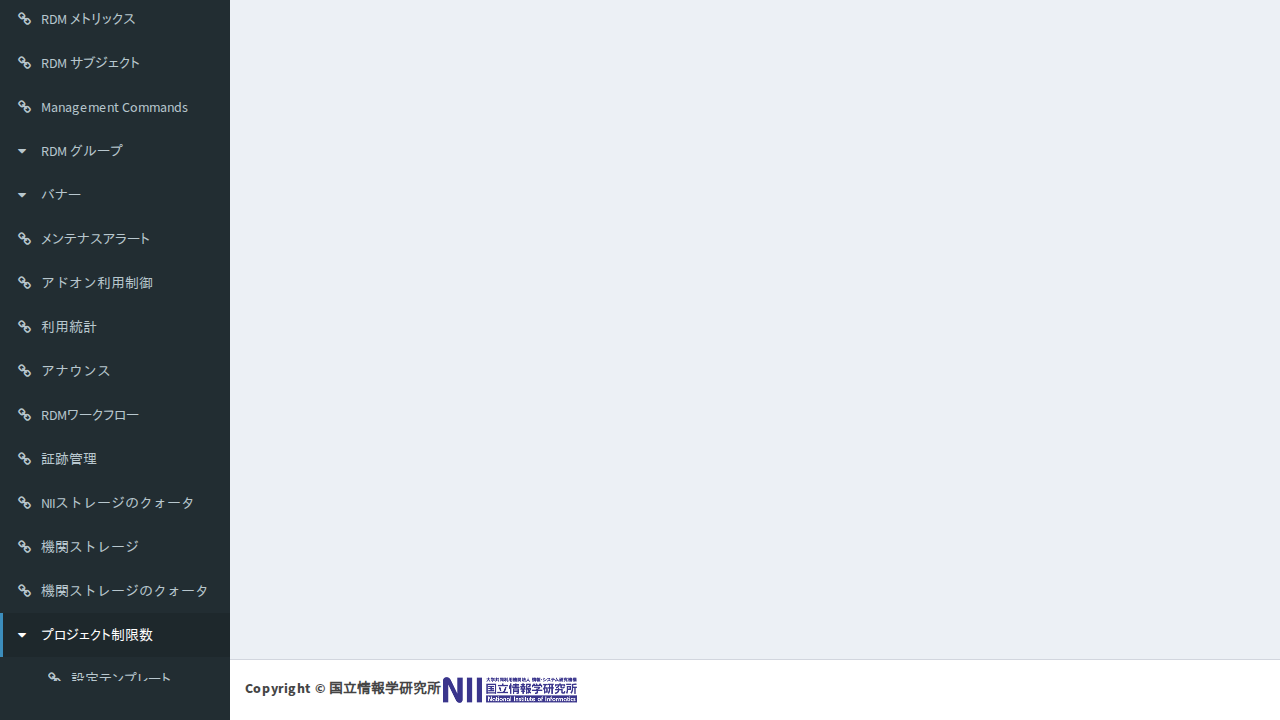

In [12]:
async def _step(page):
    await page.locator('//a[@href = "#collapseProjectLimitNumber"]').click()

    await expect(page.locator('//a[@href = "/project_limit_number/templates/"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[@href = "/project_limit_number/settings/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## サブメニューから「設定テンプレート」をクリックする

「プロジェクト作成数設定テンプレート一覧」画面が表示されること


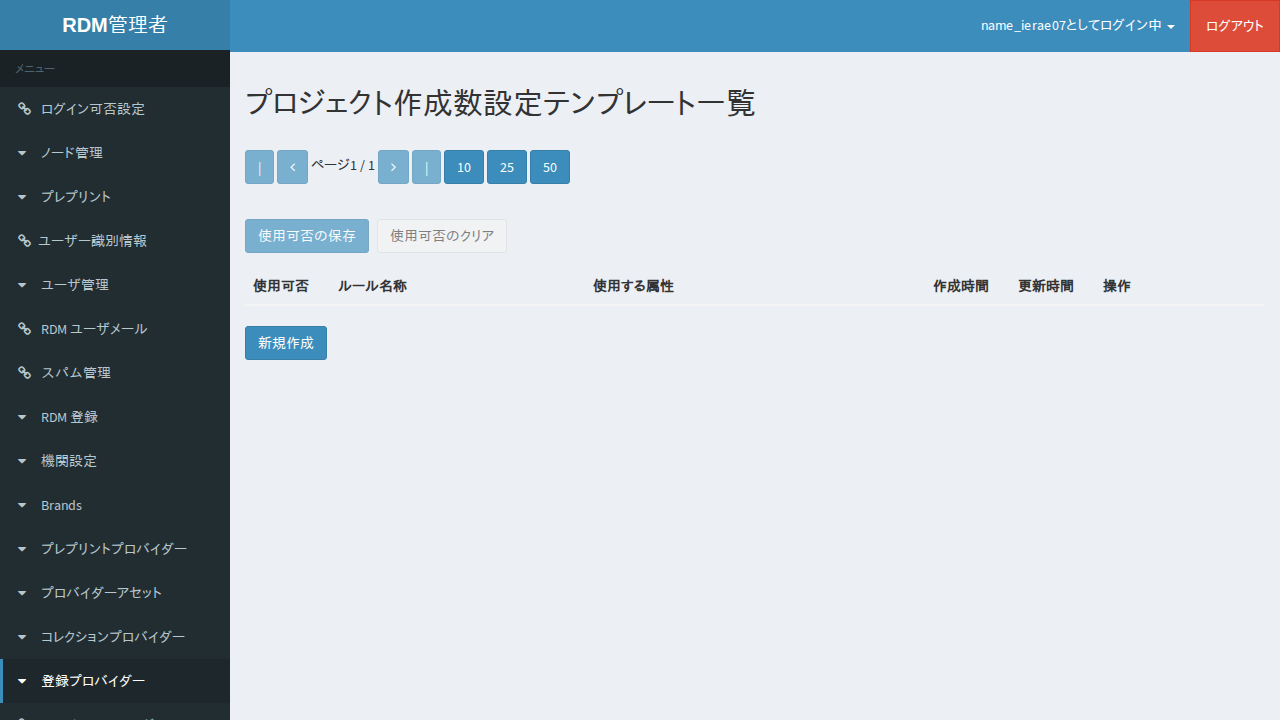

In [13]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/templates/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート一覧"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「新規作成」ボタンを押下する

「プロジェクト作成数設定テンプレート」画面が表示されること


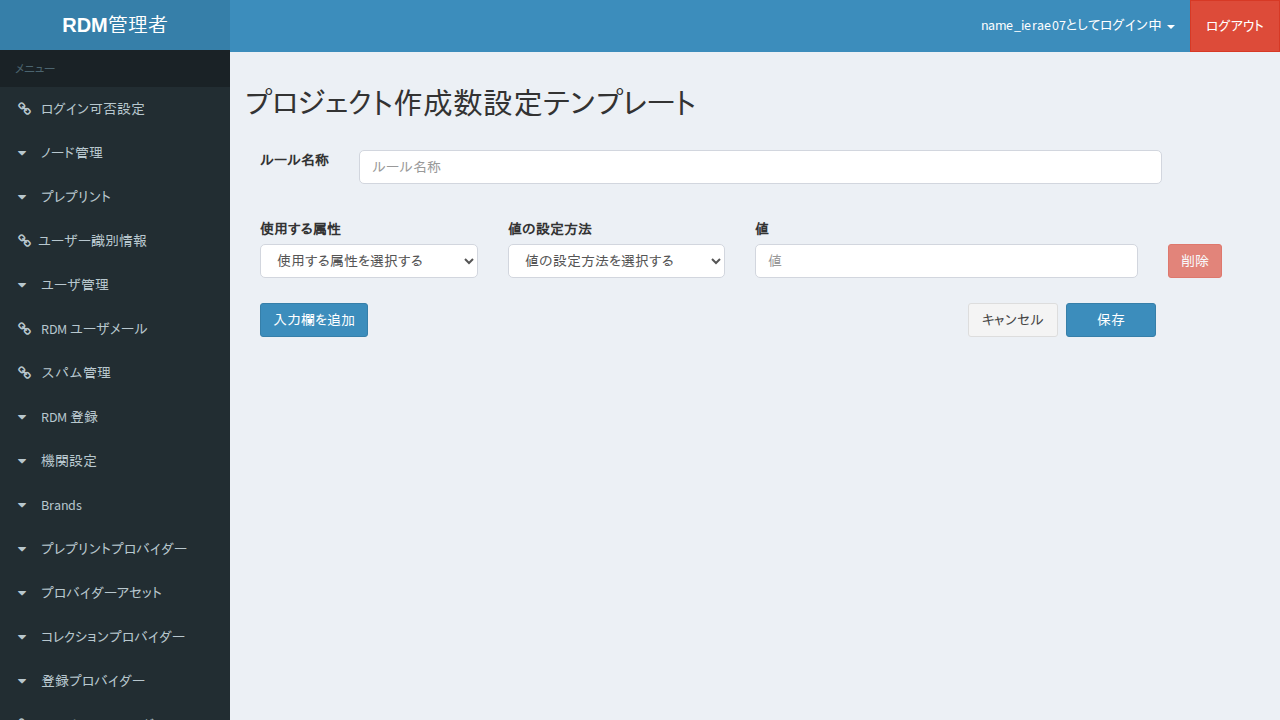

In [14]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/templates/create/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「入力欄を追加」ボタンを押下する

「使用する属性」「値の設定方法」「値」の入力列が追加されること


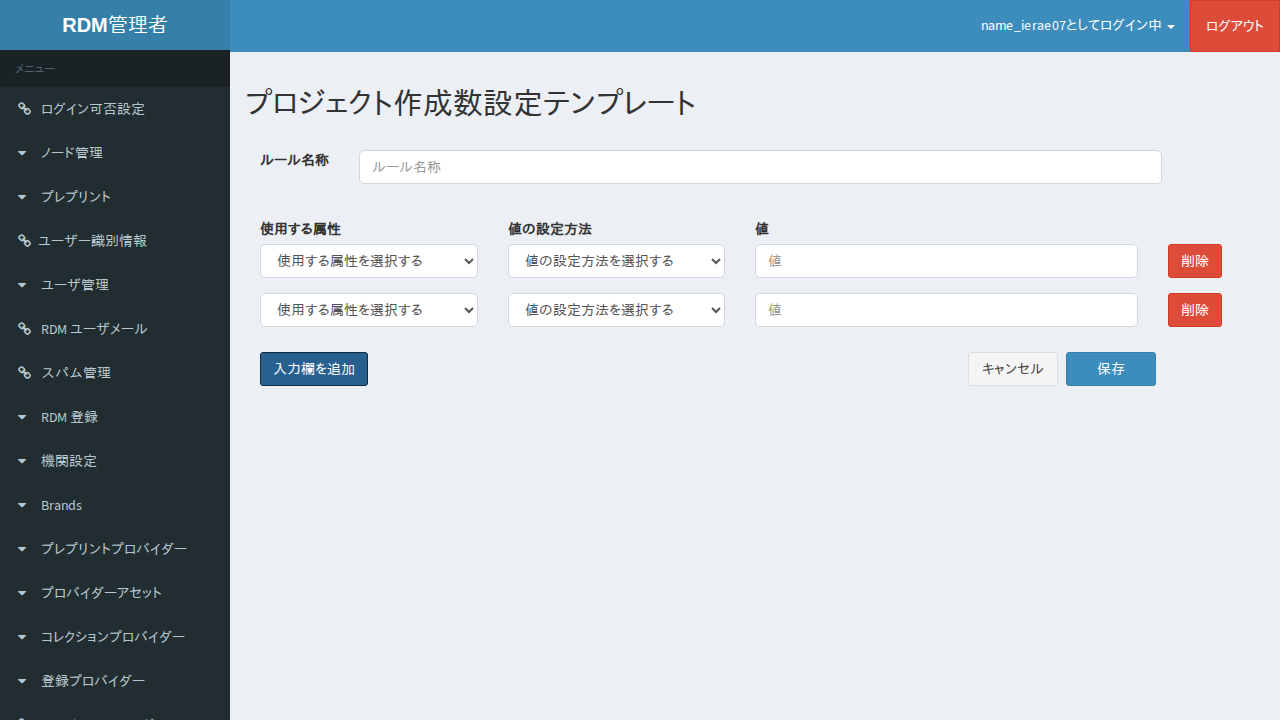

In [16]:
async def _step(page):
    # 「入力欄を追加」ボタン押下前の件数を取得
    before_count = await page.locator('#attributes_block .attribute-item').count()
    
    # 「入力欄を追加」ボタンを押下
    await page.get_by_role("button", name="入力欄を追加").click()
    
    # 入力列が1件追加されることを確認
    await expect(page.locator('#attributes_block .attribute-item')).to_have_count(before_count + 1, timeout=transition_timeout)
    
    # 追加された行を取得
    new_row = page.locator('#attributes_block .attribute-item').nth(before_count)
    
    # 「使用する属性」が存在すること
    await expect(new_row.locator('select[name="attribute_name"]')).to_be_visible(timeout=transition_timeout)
    
    # 「値の設定方法」が存在すること
    await expect(new_row.locator('select[name="setting_type"]')).to_be_visible(timeout=transition_timeout)
    
    # 「値」が存在すること
    await expect(new_row.locator('input[name="attribute_value"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## No.10で追加した列の右にある「削除」ボタンを押下する

「使用する属性」「値の設定方法」「値」の入力列が削除されること


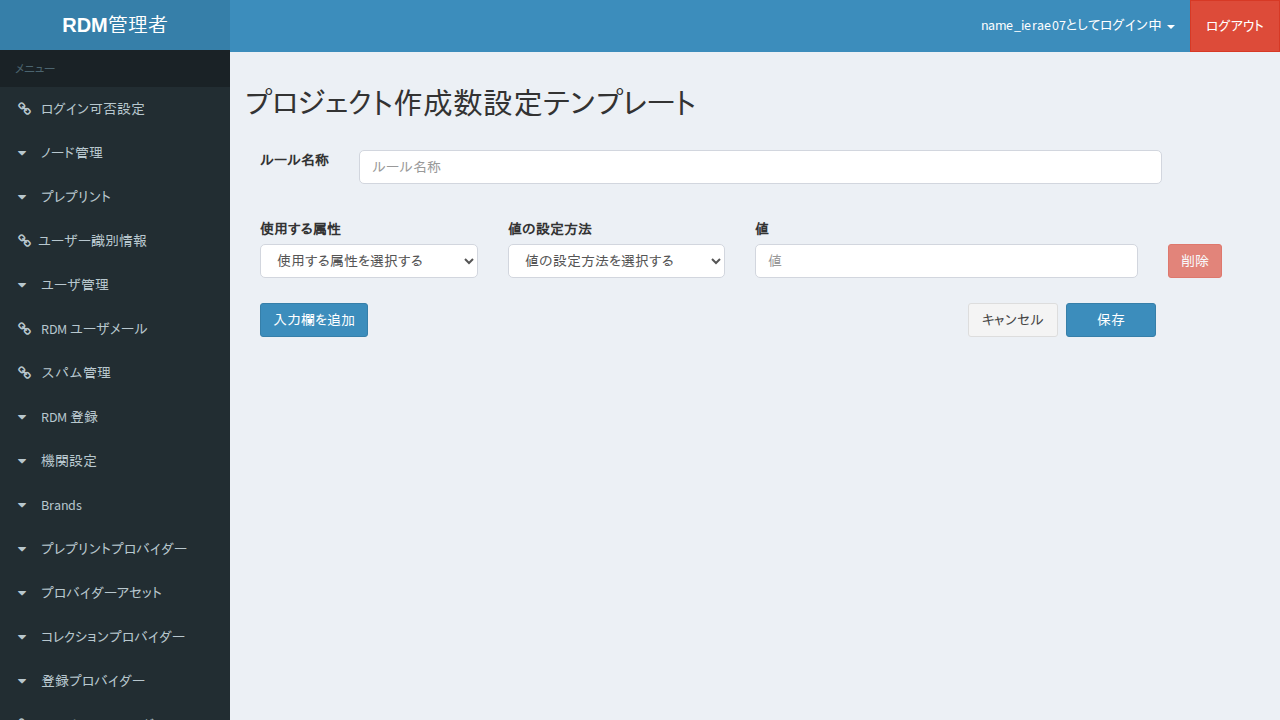

In [18]:
async def _step(page):
    # 現在の入力列数を取得
    before_count = await page.locator('#attributes_block .attribute-item').count()
    
    # No.10で追加した列（最後の列）の「削除」ボタンを押下
    new_row = page.locator('#attributes_block .attribute-item').nth(before_count - 1)

    await new_row.locator('//button[text()="削除"]').click()
    
    # 入力列が1件削除されることを確認
    await expect(page.locator('#attributes_block .attribute-item')).to_have_count(before_count - 1, timeout=transition_timeout)

await run_pw(_step)

## 「ルール名称」に「template1」、「使用する属性」に「Primary Email from GRDM」、「値の設定方法」に「単一の値(自由入力)(後方一致)」を入力する

「値」は入力不可となっていること


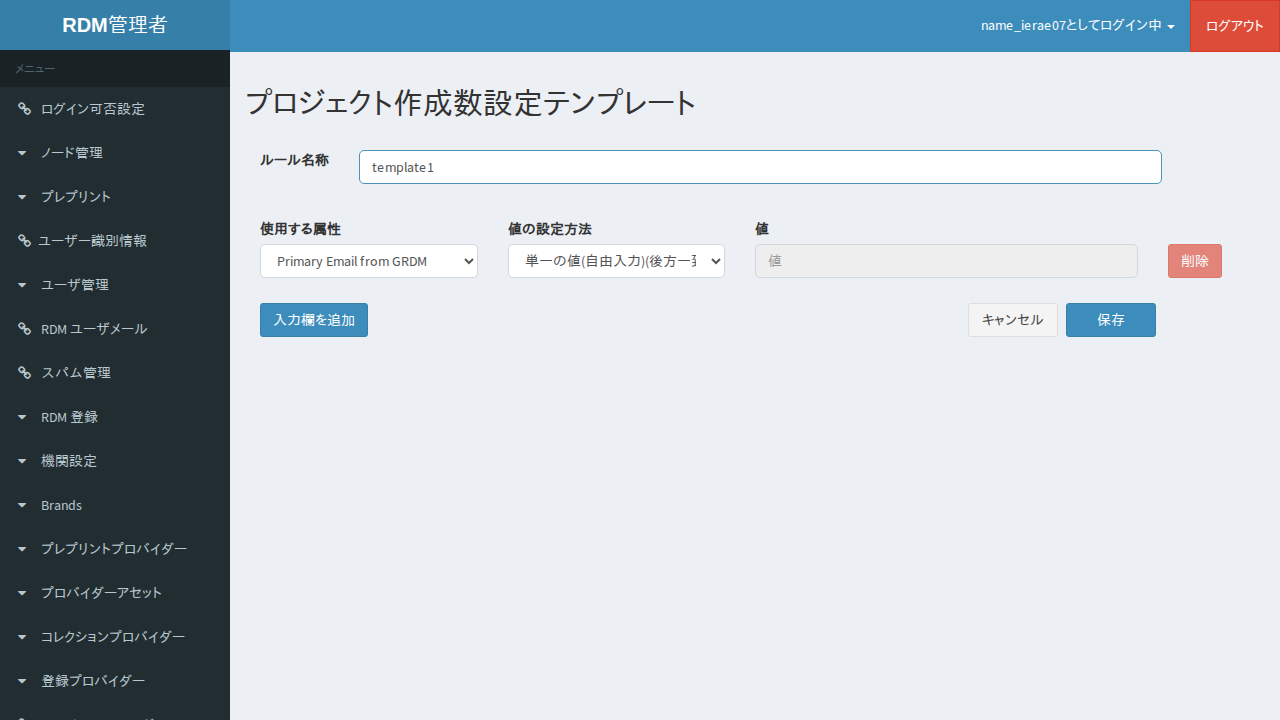

In [19]:
async def _step(page):
    # 「ルール名称」に「template1」を入力
    await page.locator('#template_name').fill('template1')
    
    # 「使用する属性」に「Primary Email from GRDM」を選択
    await page.locator('#attribute_id_0').select_option(label='Primary Email from GRDM')
    
    # 「値の設定方法」に「単一の値(自由入力)(後方一致)」を選択
    await page.locator('#setting_id_0').select_option(label='単一の値(自由入力)(後方一致)')
    
    # 「値」が入力不可となっていることを確認
    await expect( page.locator('#setting_name_0')).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定テンプレート一覧」画面に No.12 で入力した内容が追加されていること


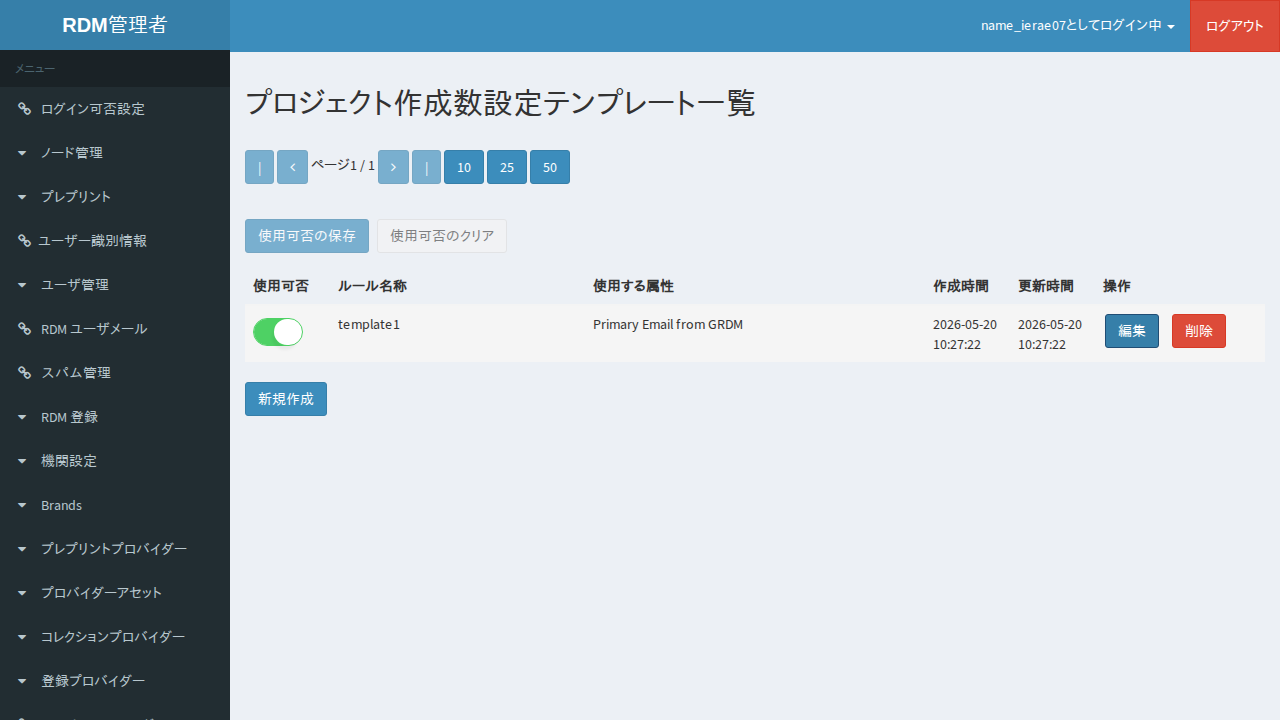

In [20]:
async def _step(page):
    await page.locator('//button[text()="保存"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート一覧"]')).to_be_visible(timeout=transition_timeout)

    table = page.locator('#setting-template-table')
    row = table.locator('tbody tr').filter(has_text='template1')
    await expect(row).to_be_visible(timeout=transition_timeout)
    
    # 「ルール名称」が表示されていること
    await expect(row).to_contain_text('template1', timeout=transition_timeout)
    
    # 「使用する属性」が表示されていること
    await expect(row).to_contain_text('Primary Email from GRDM', timeout=transition_timeout)

await run_pw(_step)

## No.13 で保存した「ルール名称」の「template1」の右端にある「編集」ボタンを押下する

No.13で保存した「ルール名称」、「使用する属性」、「値の設定方法」が「プロジェクト作成数設定テンプレート」画面に表示されること


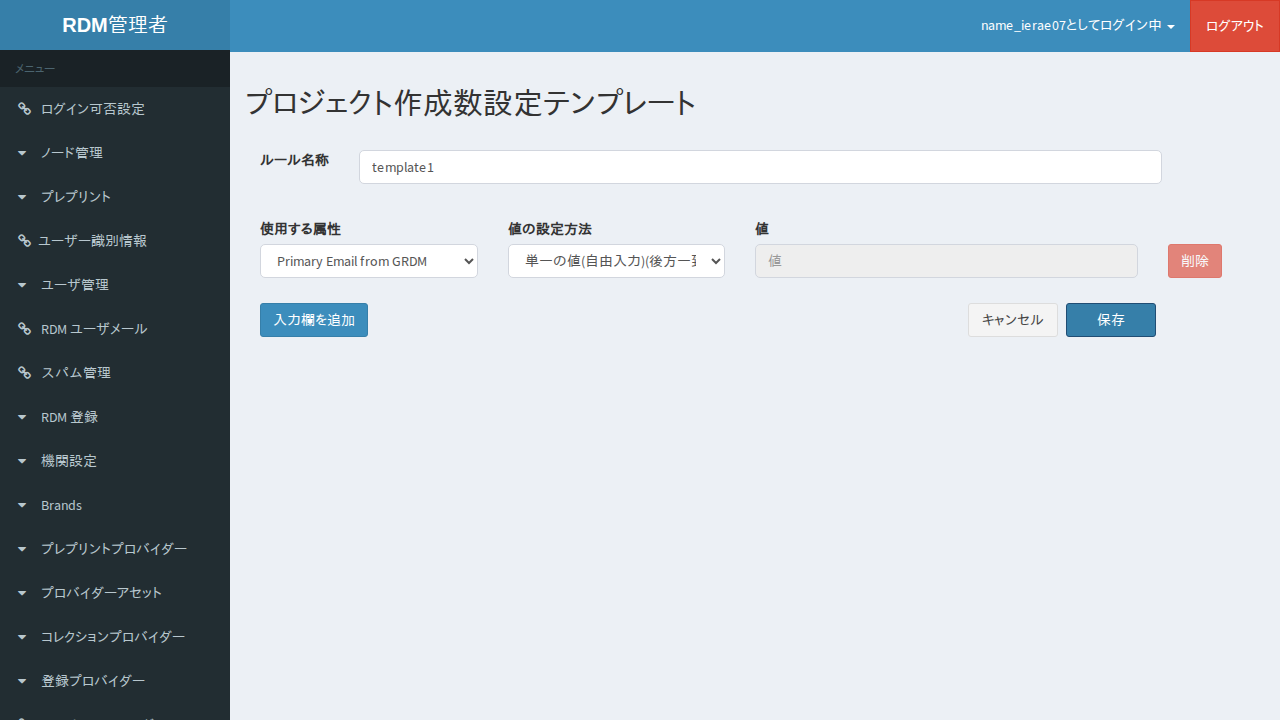

In [23]:
async def _step(page):
    # 「ルール名称」が「template1」の行を取得
    row = page.locator('#setting-template-table tbody tr').filter(has_text='template1')
    # 右端にある「編集」ボタンを押下
    await row.get_by_role("link", name="編集").click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート"]')).to_be_visible(timeout=transition_timeout)

    # 「ルール名称」が表示されていること
    await expect(page.locator('#template_name')).to_have_value('template1', timeout=transition_timeout)
    
    # 「使用する属性」に「Primary Email from GRDM」が表示されていること
    await expect(page.locator('#attribute_id_0')).to_have_value('Primary Email from GRDM', timeout=transition_timeout)
    
    # 「値の設定方法」に「単一の値(自由入力)(後方一致)」が表示されていること
    await expect(page.locator('#setting_id_0 option:checked')).to_have_text('単一の値(自由入力)(後方一致)', timeout=transition_timeout)

await run_pw(_step)

## 「使用する属性」に「Primary Email from GRDM」、「値の設定方法」を「単一の値(自由入力)(完全一致)」に変更する

「使用する属性」が「Primary Email from GRDM」、「値の設定方法」が「単一の値(自由入力)(完全一致)」に変更されること


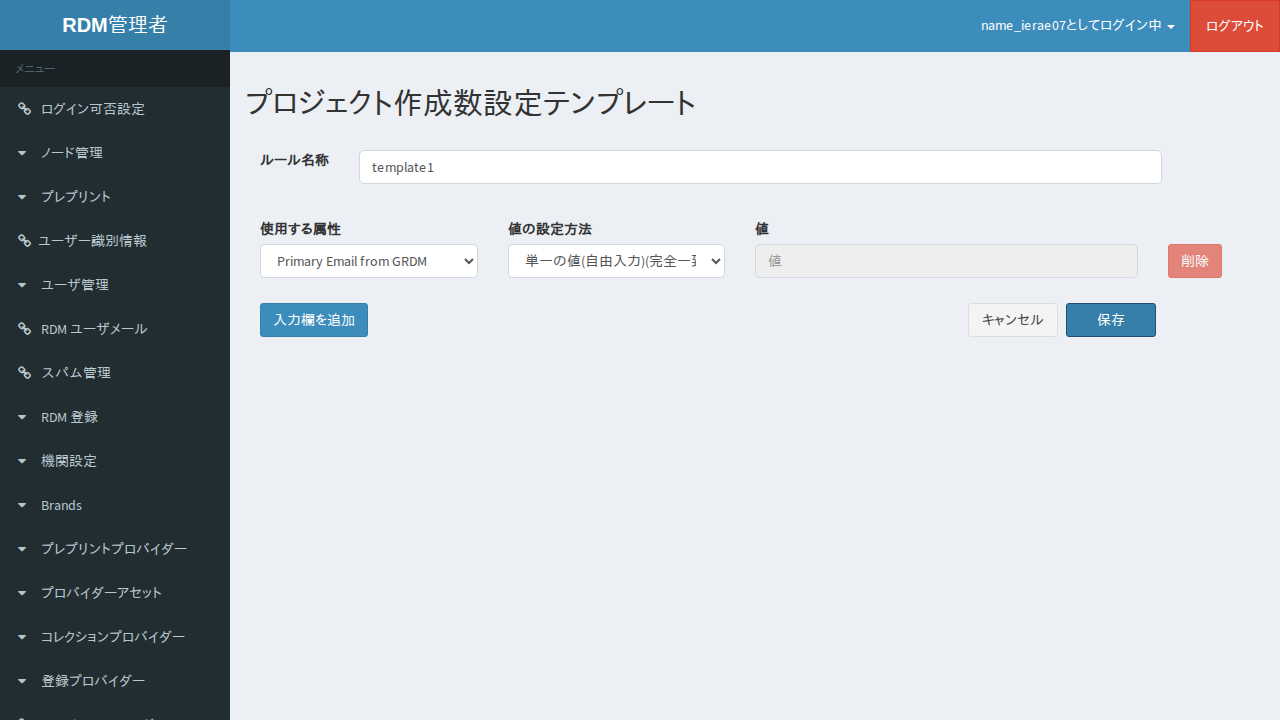

In [24]:
async def _step(page):
    # 「使用する属性」に「Primary Email from GRDM」を選択
    await page.locator('#attribute_id_0').select_option(label='Primary Email from GRDM')
    
    # 「値の設定方法」を「単一の値(自由入力)(完全一致)」に変更
    await page.locator('#setting_id_0').select_option(label='単一の値(自由入力)(完全一致)')

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定テンプレート一覧」画面にNo.15で入力した内容に変更されていること
(「プロジェクト作成数設定テンプレート一覧」画面では「使用する属性」の変更の確認が可能)


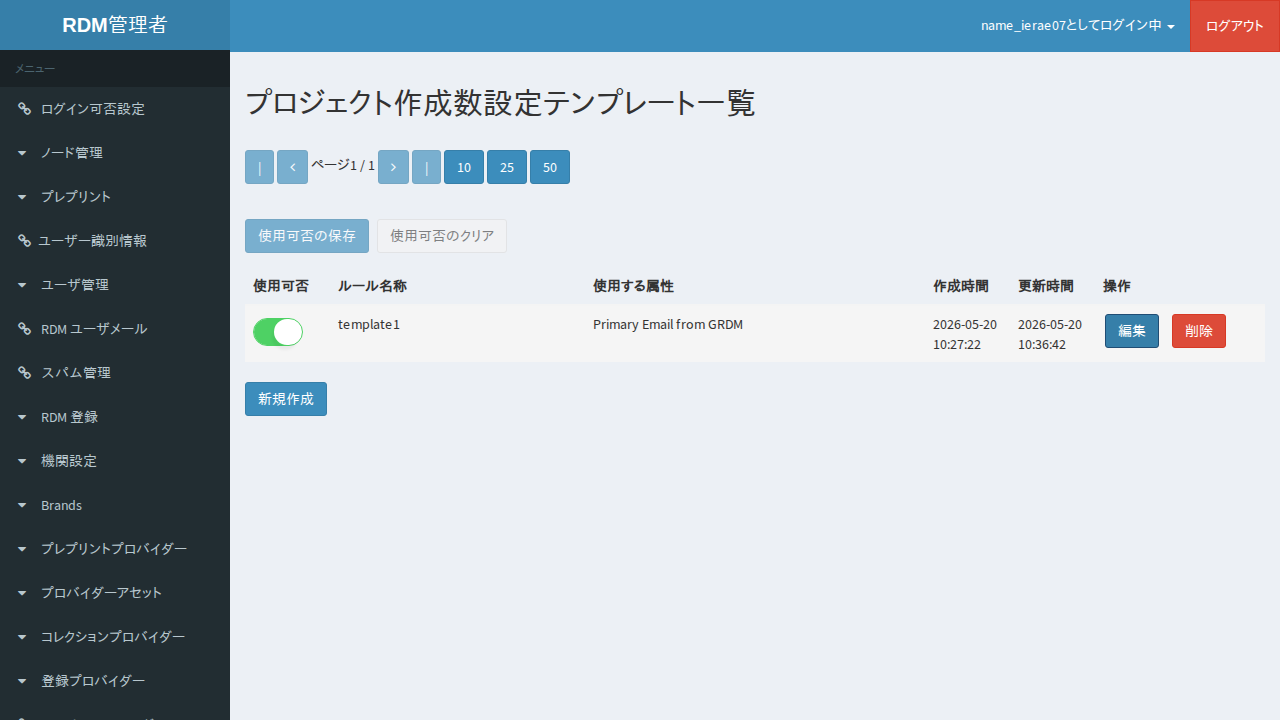

In [25]:
async def _step(page):
    await page.locator('//button[text()="保存"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート一覧"]')).to_be_visible(timeout=transition_timeout)

    row = page.locator('#setting-template-table tbody tr').filter(has_text='template1')
    await expect(row).to_be_visible(timeout=transition_timeout)
    
    # 「ルール名称」が表示されていること
    await expect(row).to_contain_text('template1', timeout=transition_timeout)
    
    # 「使用する属性」が表示されていること
    await expect(row).to_contain_text('Primary Email from GRDM', timeout=transition_timeout)

await run_pw(_step)

## 「新規作成」ボタンを押下する

「プロジェクト作成数設定テンプレート」画面が表示されること


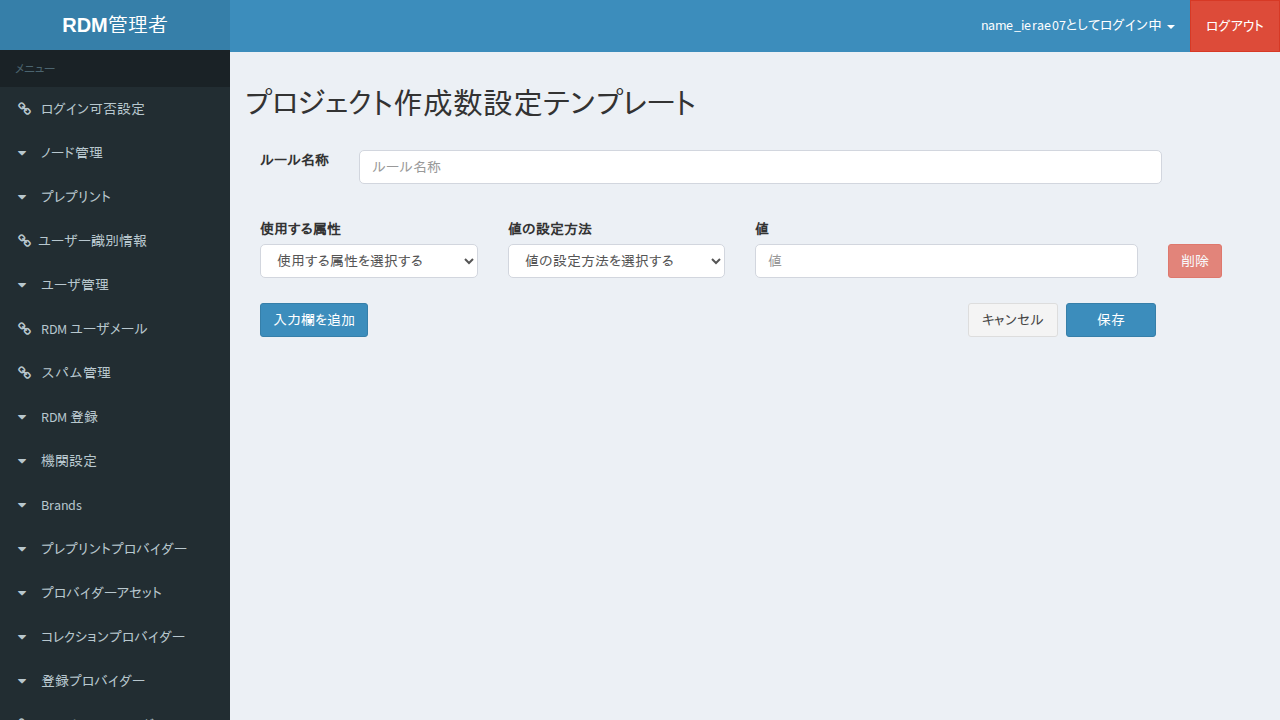

In [26]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/templates/create/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「ルール名称」に「template2」、「使用する属性」に「mail」、「値の設定方法」に「固定値(後方一致)」、「@gmail」を入力する

「値」は入力可能となっていること


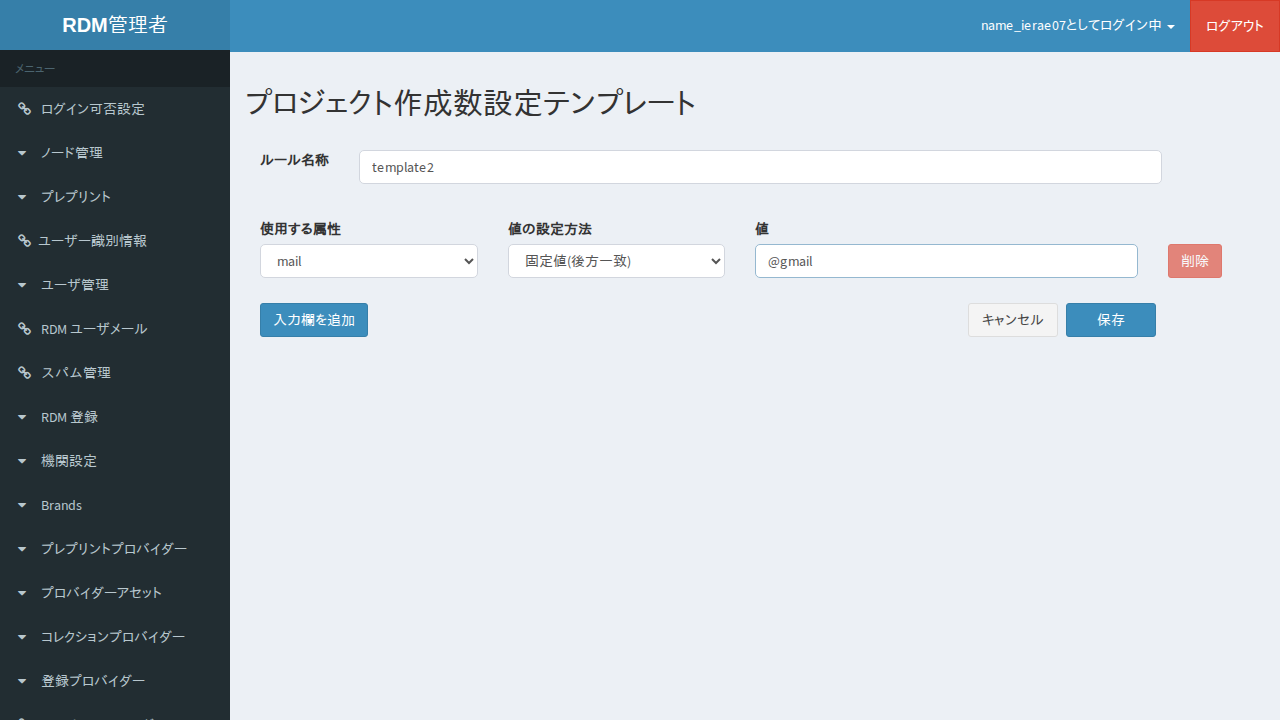

In [27]:
async def _step(page):
    # 「ルール名称」に「template2」を入力
    await page.locator('#template_name').fill('template2')
    
    # 「使用する属性」に「mail」を選択
    await page.locator('#attribute_id_0').select_option(label='mail')
    
    # 「値の設定方法」に「固定値(後方一致)」を選択
    await page.locator('#setting_id_0').select_option(label='固定値(後方一致)')
    
    # 「値」が入力可能となっていることを確認
    await expect(page.locator('#setting_name_0')).to_be_editable(timeout=transition_timeout)
    
    # 「値」に「@gmail」を入力
    await page.locator('#setting_name_0').fill('@gmail')

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定テンプレート一覧」画面に No.18 で入力した内容が追加されていること


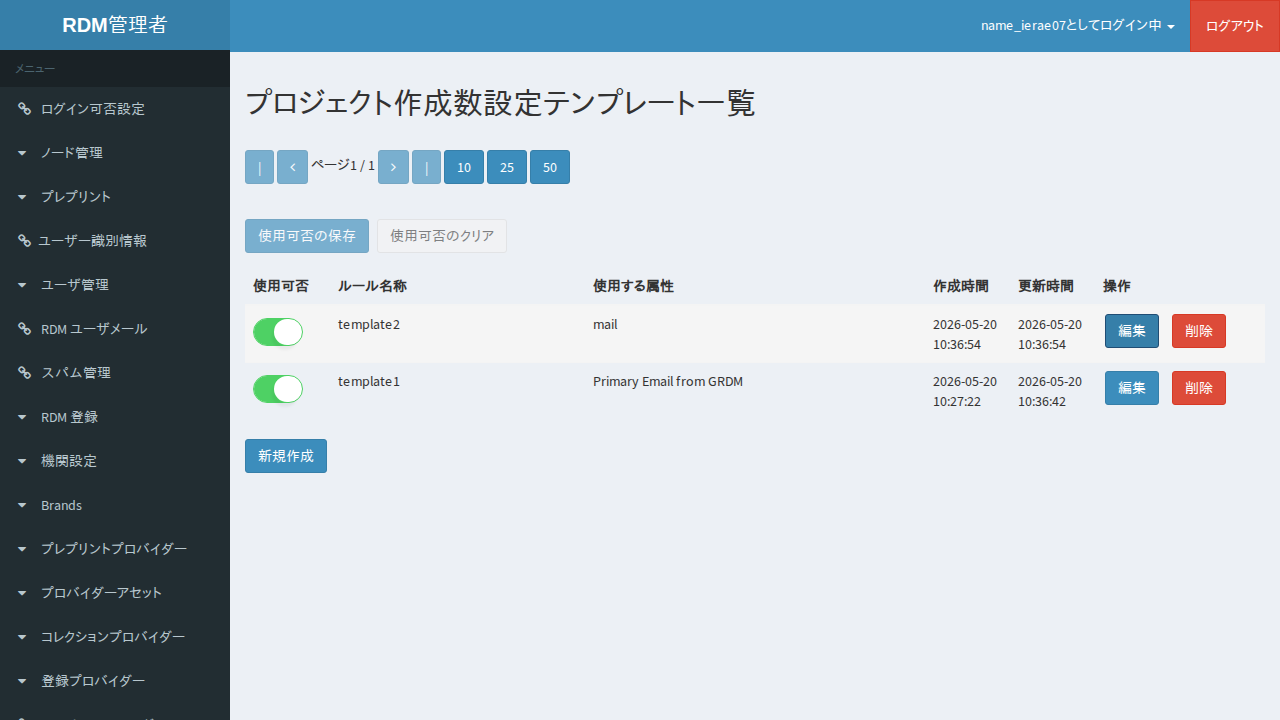

In [28]:
async def _step(page):
    await page.locator('//button[text()="保存"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート一覧"]')).to_be_visible(timeout=transition_timeout)

    table = page.locator('#setting-template-table')
    row = table.locator('tbody tr').filter(has_text='template2')
    await expect(row).to_be_visible(timeout=transition_timeout)
    
    # 「ルール名称」が表示されていること
    await expect(row).to_contain_text('template2', timeout=transition_timeout)
    
    # 「使用する属性」が表示されていること
    await expect(row).to_contain_text('mail', timeout=transition_timeout)

await run_pw(_step)

## 「新規作成」ボタンを押下する

「プロジェクト作成数設定テンプレート」画面が表示されること


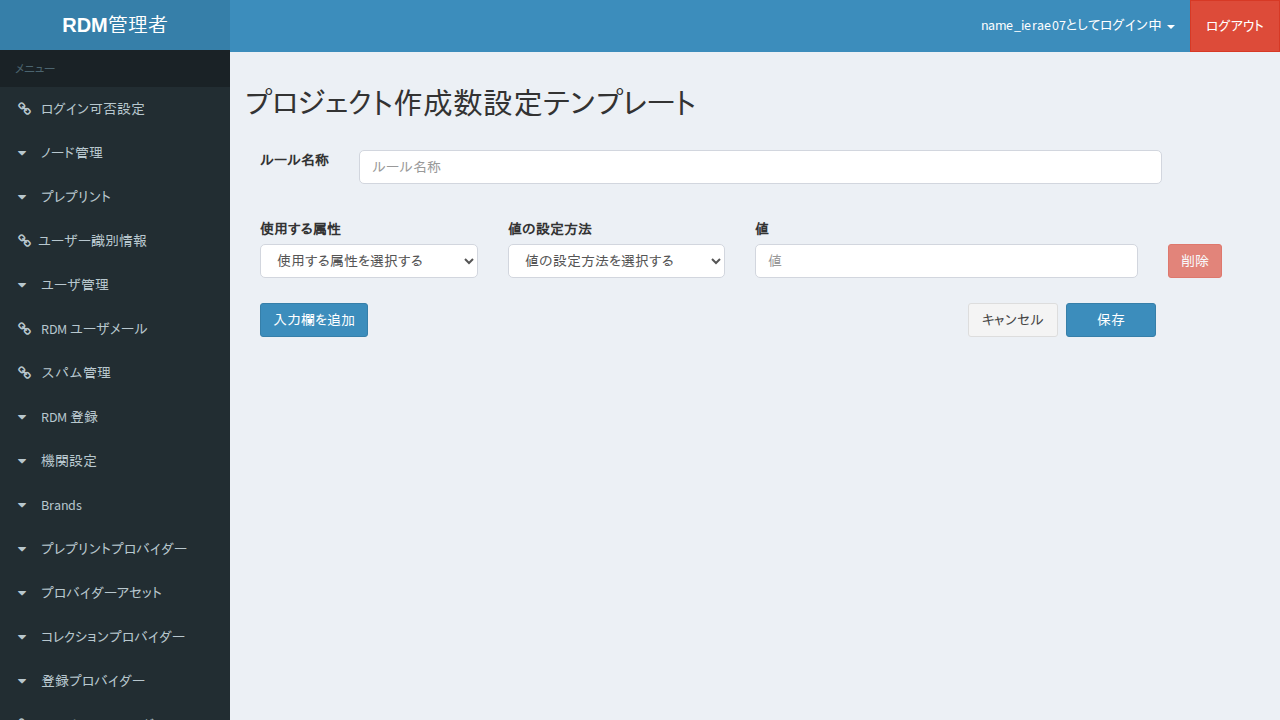

In [29]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/templates/create/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「ルール名称」に「template3」、「使用する属性」に「mail」、「値の設定方法」に「固定値(後方一致)」、「@gmail.com」を入力する

「値」は入力可能となっていること


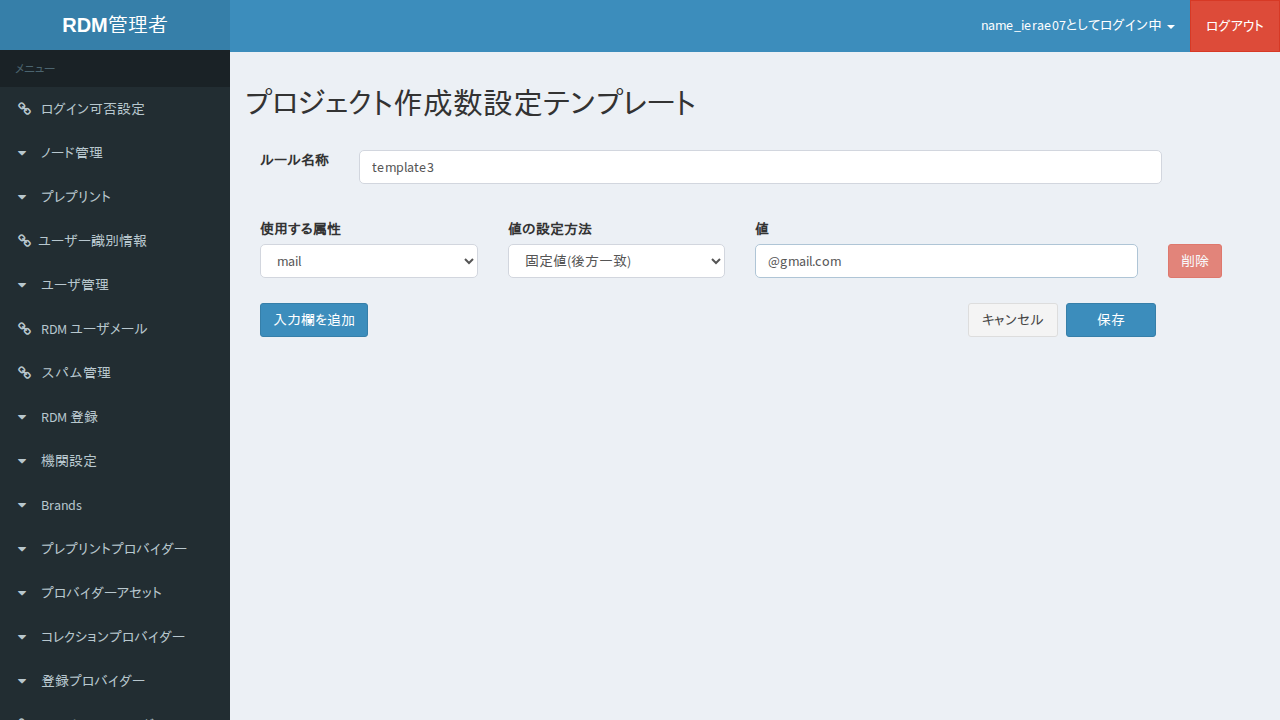

In [30]:
async def _step(page):
    # 「ルール名称」に「template3」を入力
    await page.locator('#template_name').fill('template3')
    
    # 「使用する属性」に「mail」を選択
    await page.locator('#attribute_id_0').select_option(label='mail')
    
    # 「値の設定方法」に「固定値(後方一致)」を選択
    await page.locator('#setting_id_0').select_option(label='固定値(後方一致)')
    
    # 「値」が入力可能となっていることを確認
    await expect(page.locator('#setting_name_0')).to_be_editable(timeout=transition_timeout)
    
    # 「値」に「@gmail.com」を入力
    await page.locator('#setting_name_0').fill('@gmail.com')

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定テンプレート一覧」画面にNo.21で入力した内容が追加されていること


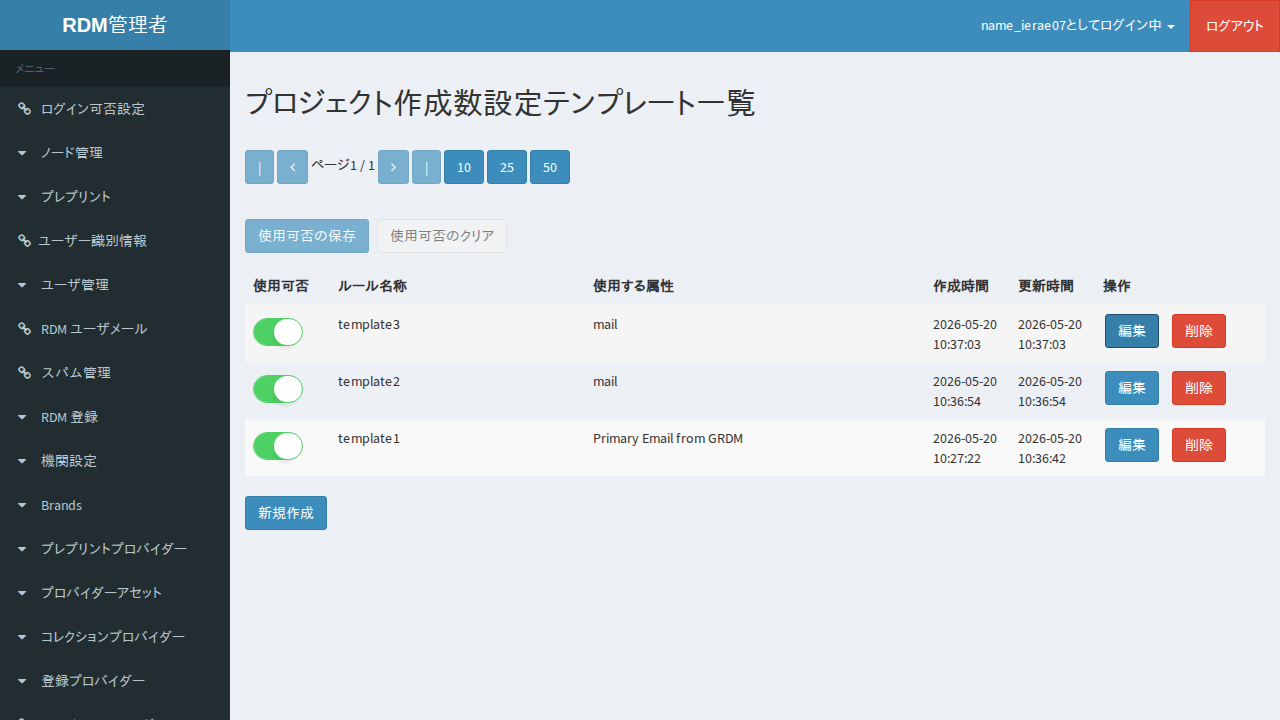

In [31]:
async def _step(page):
    await page.locator('//button[text()="保存"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート一覧"]')).to_be_visible(timeout=transition_timeout)

    row = page.locator('#setting-template-table tbody tr').filter(has_text='template3')
    await expect(row).to_be_visible(timeout=transition_timeout)
    
    # 「ルール名称」が表示されていること
    await expect(row).to_contain_text('template3', timeout=transition_timeout)
    
    # 「使用する属性」が表示されていること
    await expect(row).to_contain_text('mail', timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト作成数設定テンプレート一覧」画面でNo.19で作成した「ルール名称」の「template2」の右端にある「削除」ボタンを押下する

「このテンプレートを削除してもよろしいですか?」というメッセージが記載されたダイアログが表示されること


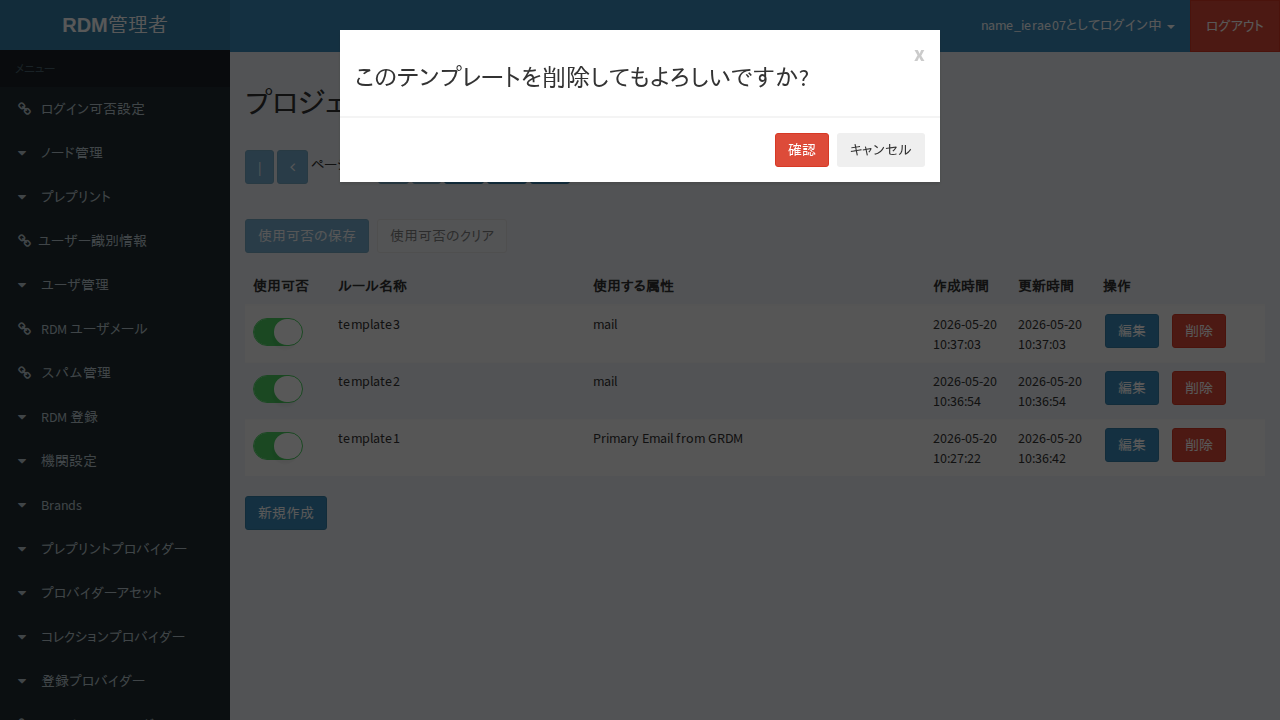

In [32]:
async def _step(page):
    # 「template2」の行にある「削除」ボタンを押下
    row = page.locator('#setting-template-table tbody tr').filter(has_text='template2')
    await row.locator('button[id^="delete_template_setting_"]').click()

    # 削除確認ダイアログが表示されること
    dialog = page.locator('#deleteSettingTemplate')
    await expect(dialog).to_be_visible(timeout=transition_timeout)
    await expect(dialog.locator('h3')).to_have_text('このテンプレートを削除してもよろしいですか?', timeout=transition_timeout)

await run_pw(_step)

## 「確認」ボタンを押下する

「プロジェクト作成数設定テンプレート一覧」画面で No.26 で作成した「ルール名称」の「template2」のテンプレートが削除されること


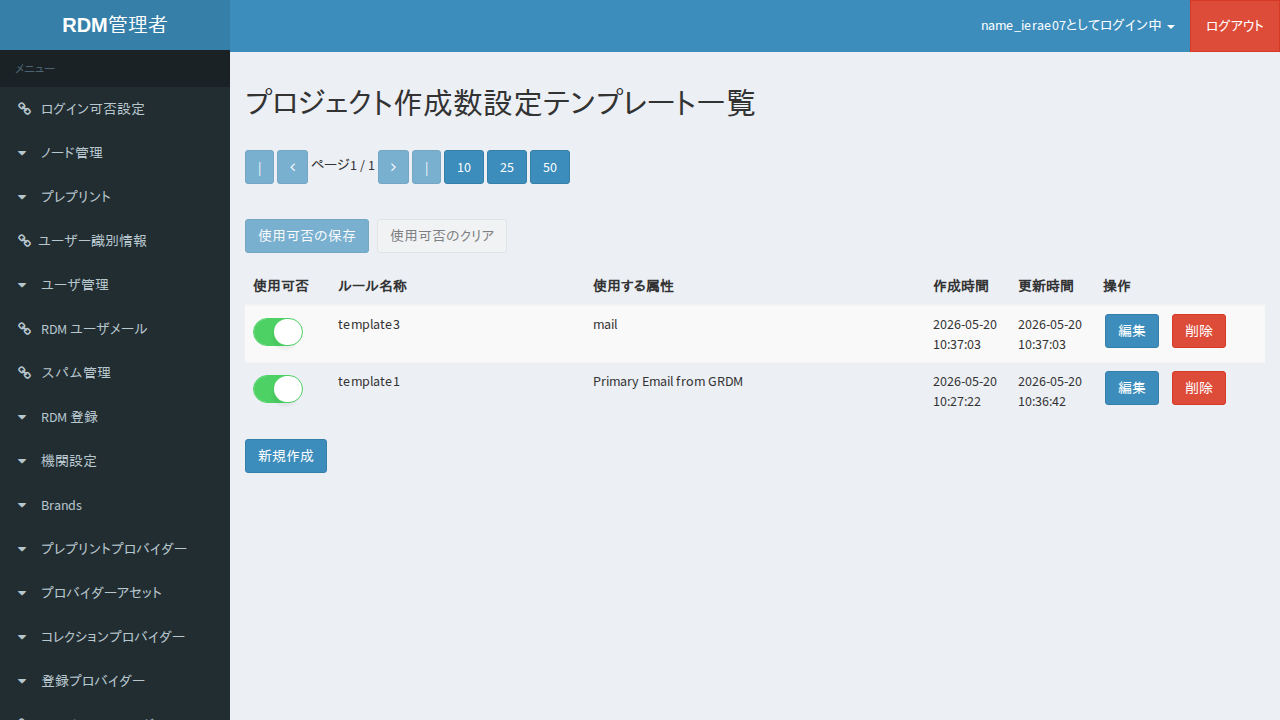

In [33]:
async def _step(page):
    # 「確認」ボタンを押下し、削除後の再読み込み完了を待機
    async with page.expect_navigation(wait_until='load', timeout=transition_timeout):
        await page.locator('#submitDeleteButton').click()

    # 「template2」のテンプレートが一覧から削除されること
    row = page.locator('#setting-template-table tbody tr').filter(has_text='template2')
    await expect(row).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## No.22 で保存した「ルール名称」の「template3」の左にある「使用可否」のトグルボタンを押下する

「使用可否」のトグルボタンが変わり、「使用可否の保存」と「使用可否のクリア」が有効になること


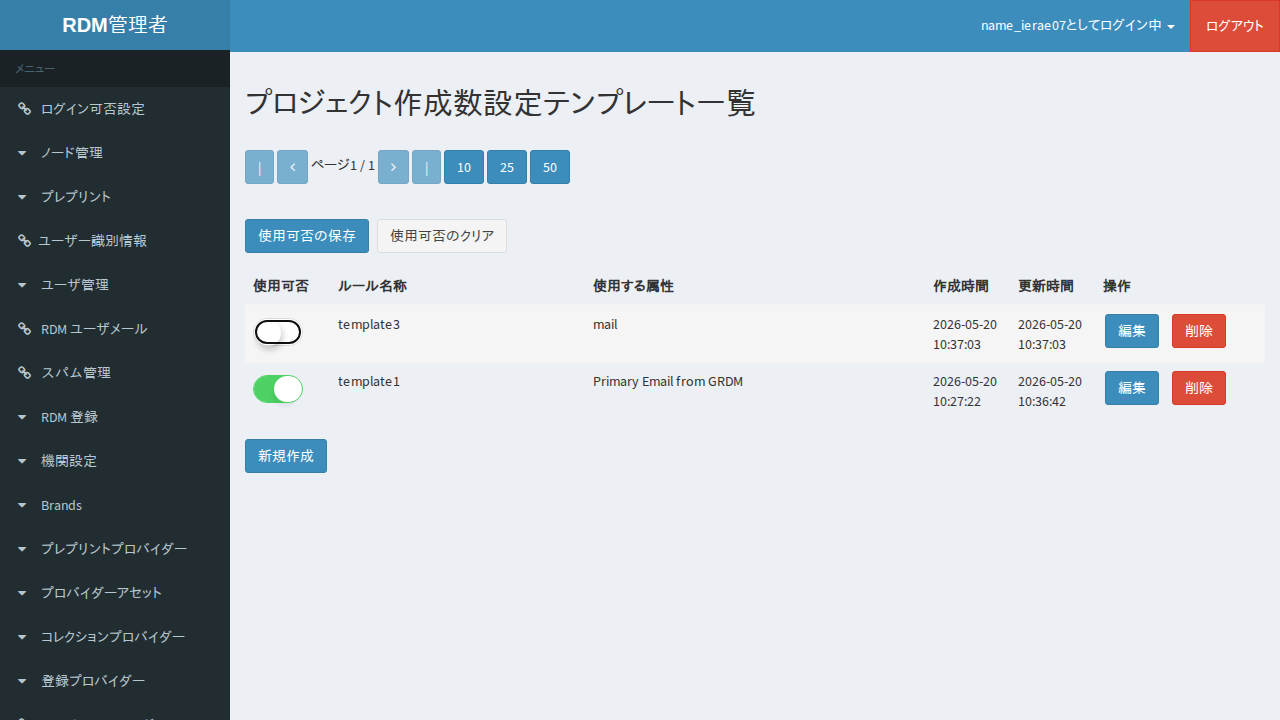

In [34]:
async def _step(page):
    # 「template3」の左にある「使用可否」のトグルボタンを押下
    row = page.locator('#setting-template-table tbody tr').filter(has_text='template3')
    toggle_button = row.locator('input[name="is_availability"]')
    await toggle_button.click()

    # 「使用可否」のトグルボタンが変更されていることを確認
    await expect(toggle_button).to_have_value('off', timeout=transition_timeout)
    
    # 「使用可否の保存」が有効になることを確認
    await expect(page.locator('#save_availability')).to_be_enabled(timeout=transition_timeout)
    
    # 「使用可否のクリア」が有効になることを確認
    await expect(page.locator('#clear_availability')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「使用可否のクリア」ボタンを押下する

No.25 の「使用可否」のトグルボタンが変更前の状態に戻ること


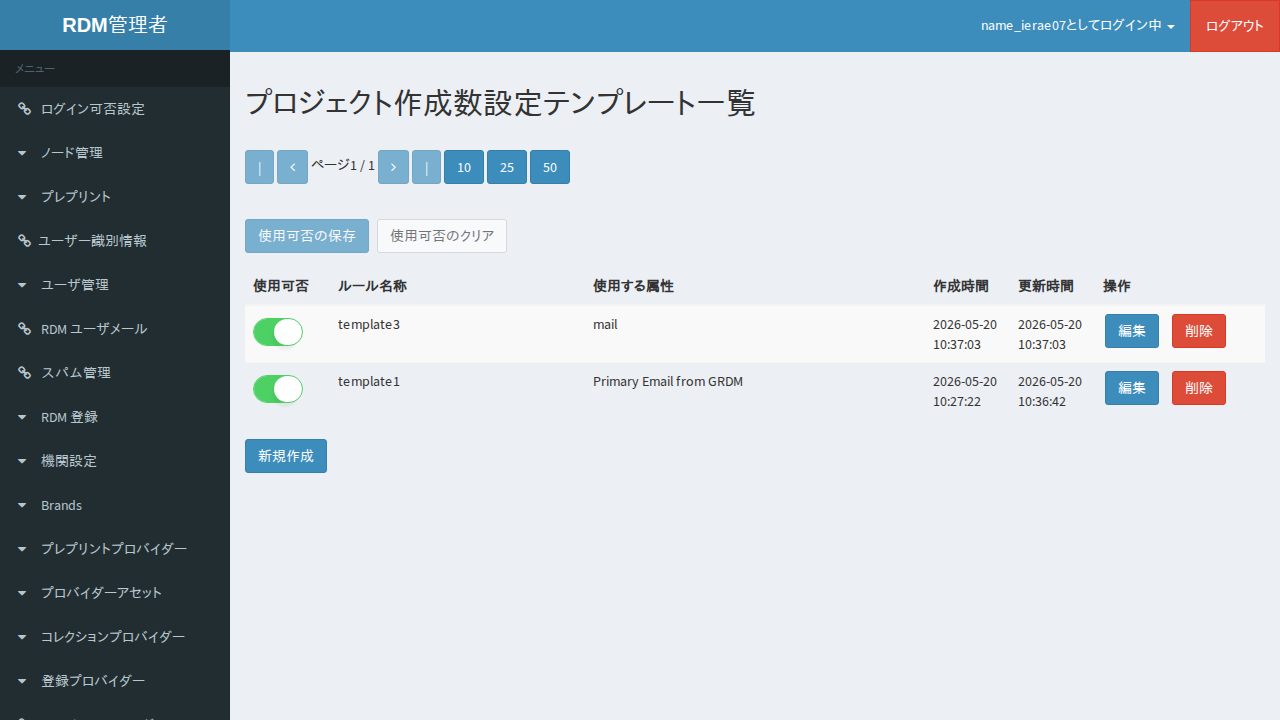

In [35]:
async def _step(page):
    # 「使用可否のクリア」ボタンを押下
    await page.locator('#clear_availability').click()

    #「使用可否」のトグルボタンが変更前の状態に戻ること
    row = page.locator('#setting-template-table tbody tr').filter(has_text='template3')
    toggle_button = row.locator('input[name="is_availability"]')
    await expect(toggle_button).to_have_value('on', timeout=transition_timeout)
    await expect(page.locator('#save_availability')).to_be_disabled(timeout=transition_timeout)
    await expect(page.locator('#clear_availability')).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## No.22 で保存した「ルール名称」の「template3」の左にある「使用可否」のトグルボタンを再び押下する

「使用可否」のトグルボタンが変わり、「使用可否の保存」と「使用可否のクリア」が有効になること


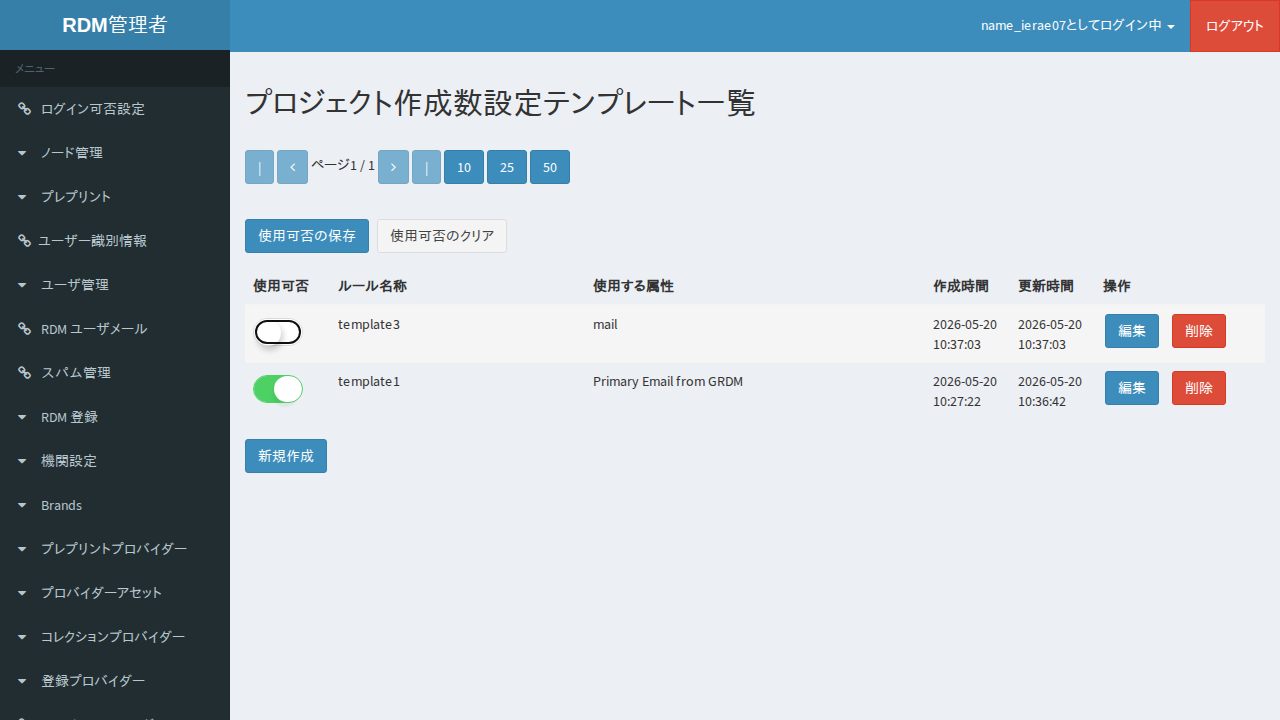

In [ ]:
async def _step(page):
    # 「template3」の左にある「使用可否」のトグルボタンを押下
    row = page.locator('#setting-template-table tbody tr').filter(has_text='template3')
    toggle_button = row.locator('input[name="is_availability"]')
    await toggle_button.click()

    # 「使用可否」のトグルボタンが変更されていることを確認
    assert "checked" not in (await toggle_button.get_attribute("class"))
    
    # 「使用可否の保存」が有効になることを確認
    await expect(page.locator('#save_availability')).to_be_enabled(timeout=transition_timeout)
    
    # 「使用可否のクリア」が有効になることを確認
    await expect(page.locator('#clear_availability')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「使用可否の保存」ボタンを押下する

No.27 の「使用可否」のトグルボタンの状態が確定し、「使用可否の保存」と「使用可否のクリア」が無効になること


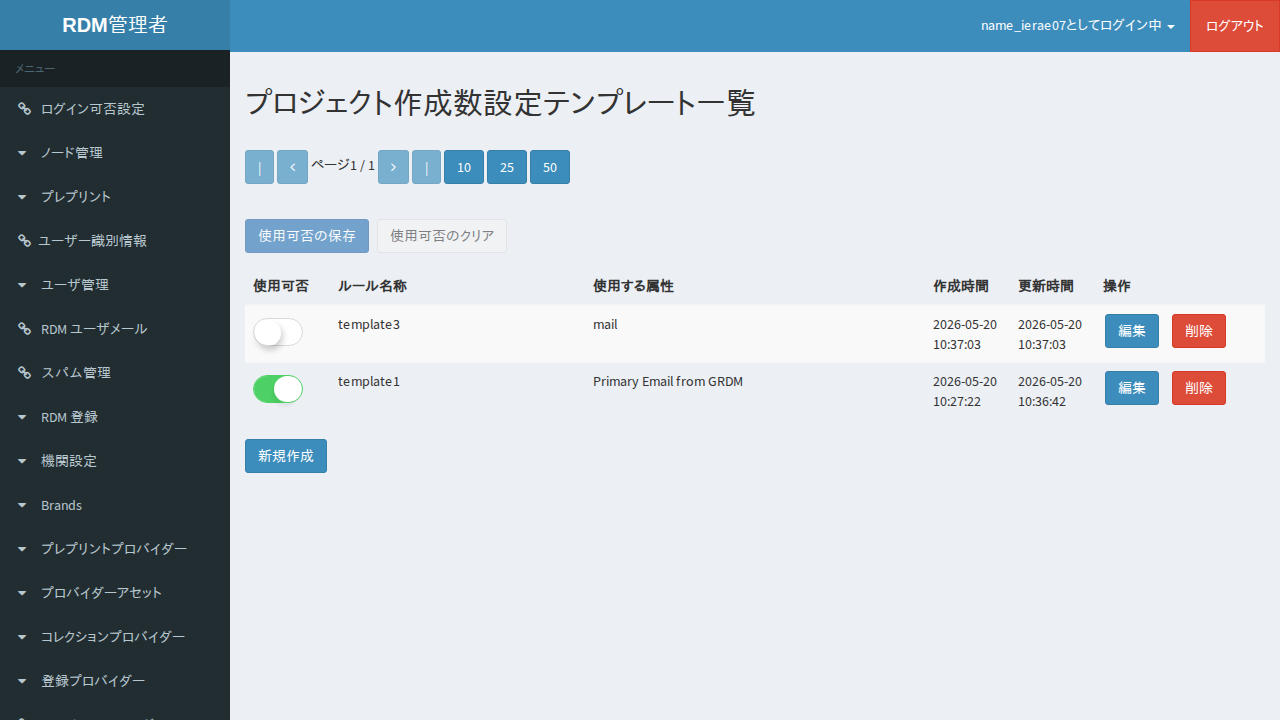

In [37]:
async def _step(page):
    # 「使用可否の保存」ボタンを押下し、保存後の再読み込み完了を待機
    async with page.expect_navigation(wait_until='load', timeout=transition_timeout):
        await page.locator('#save_availability').click()
    
    # 「使用可否」のトグルボタンの状態が確定していることを確認
    row = page.locator('#setting-template-table tbody tr').filter(has_text='template3')
    toggle_button = row.locator('input[name="is_availability"]')
    await expect(toggle_button).to_have_value('off', timeout=transition_timeout)
    
    # 「使用可否の保存」が無効になることを確認
    await expect(page.locator('#save_availability')).to_be_disabled(timeout=transition_timeout)
    
    # 「使用可否のクリア」が無効になることを確認
    await expect(page.locator('#clear_availability')).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}